# Project 1: Auto Insurance Claims Analysis

## Business Context
Analysis of 1,000 auto insurance claims to identify fraud predictors, high-cost segments, and risk patterns across incident types, collision types, and customer demographics.

## Dataset
- 1,000 claims across Ohio, Indiana, and Illinois
- 40 variables including incident type, severity, claim amounts, 
  and fraud flag
- Source: Kaggle Auto Insurance Claims Dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 

df = pd.read_csv('Week1/insurance_claims.csv')

print(df.shape)
print(df.head())

(1000, 40)
   months_as_customer  age  policy_number policy_bind_date policy_state  \
0                 328   48         521585       2014-10-17           OH   
1                 228   42         342868       2006-06-27           IN   
2                 134   29         687698       2000-09-06           OH   
3                 256   41         227811       1990-05-25           IL   
4                 228   44         367455       2014-06-06           IL   

  policy_csl  policy_deductable  policy_annual_premium  umbrella_limit  \
0    250/500               1000                1406.91               0   
1    250/500               2000                1197.22         5000000   
2    100/300               2000                1413.14         5000000   
3    250/500               2000                1415.74         6000000   
4   500/1000               1000                1583.91         6000000   

   insured_zip  ... police_report_available total_claim_amount injury_claim  \
0       466132

In [2]:
# Dropping empty column
df = df.drop(columns=['_c39'])

# checking missing values
print(df.isnull().sum()[df.isnull().sum() > 0])

#checking for ? values in key columns
print(df['authorities_contacted'].value_counts())
print(df['police_report_available'].value_counts())
print(df['collision_type'].value_counts())

authorities_contacted    91
dtype: int64
authorities_contacted
Police       292
Fire         223
Other        198
Ambulance    196
Name: count, dtype: int64
police_report_available
?      343
NO     343
YES    314
Name: count, dtype: int64
collision_type
Rear Collision     292
Side Collision     276
Front Collision    254
?                  178
Name: count, dtype: int64


In [3]:
# Replacing ? with Unknown in text columns
df['police_report_available'] = df['police_report_available'].replace('?', 'Unknown')
df['collision_type'] = df['collision_type'].replace('?', 'Unknown')

# Filling missing authorities_contacted with Unknown
df['authorities_contacted'] = df['authorities_contacted'].fillna('Unknown')

# Verifying fixes
print(df['police_report_available'].value_counts())
print(df['collision_type'].value_counts())
print(df['authorities_contacted'].value_counts())

# Confirming no more missing values
print("\nRemaining nulls:")
print(df.isnull().sum()[df.isnull().sum() > 0])

police_report_available
Unknown    343
NO         343
YES        314
Name: count, dtype: int64
collision_type
Rear Collision     292
Side Collision     276
Front Collision    254
Unknown            178
Name: count, dtype: int64
authorities_contacted
Police       292
Fire         223
Other        198
Ambulance    196
Unknown       91
Name: count, dtype: int64

Remaining nulls:
Series([], dtype: int64)


In [4]:
# Question 1: Fraud rate by incident type 
fraud_by_type = df.groupby('incident_type')['fraud_reported'].value_counts(
    normalize=True).round(3) * 100

fraud_by_type = fraud_by_type.unstack()
print(fraud_by_type)

fraud_reported               N     Y
incident_type                       
Multi-vehicle Collision   72.8  27.2
Parked Car                90.5   9.5
Single Vehicle Collision  71.0  29.0
Vehicle Theft             91.5   8.5


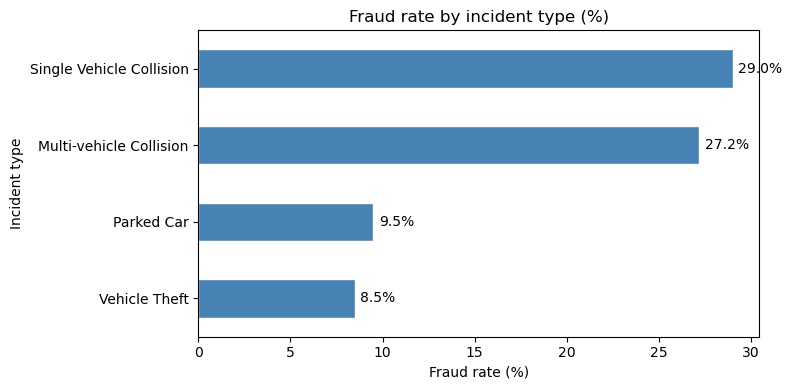

In [5]:
# Bar chart - fraud rate by incident type
ax = fraud_by_type['Y'].sort_values().plot(
    kind='barh',
    figsize=(8,4),
    color='steelblue',
    edgecolor='white')

plt.title('Fraud rate by incident type (%)')
plt.xlabel('Fraud rate (%)')
plt.ylabel('Incident type')

for i, v in enumerate(fraud_by_type['Y'].sort_values()):
    ax.text(v + 0.3, i, f'{round(v,1)}%', va='center', fontsize=10)

plt.tight_layout()
plt.show()
         

Single vehicle collision claims have the highest fraud rate at 29.0%, followed by multi-vehicle collision at 27.2%. Parked car and vehicle theft are negligible in comparison. Collision-type incidents should be the primary focus of fraud investigation efforts. 

In [6]:
# Group severity into two categories
def categorize_severity(x):
    if x in ['Major Damage', 'Total Loss']:
        return 'Serious'
    else:
        return 'Minor'

df['severity_group'] = df['incident_severity'].apply(categorize_severity)

print(df['severity_group'].value_counts())

severity_group
Serious    556
Minor      444
Name: count, dtype: int64


In [7]:
# Total claim cost by region and severity group
regional_severity = df.groupby(['incident_state', 'severity_group'])[
    'total_claim_amount'].sum().round(0).unstack()

print(regional_severity)

severity_group    Minor  Serious
incident_state                  
NC              1965730  3455500
NY              6103440  8670330
OH               228660   916060
PA               448580  1038570
SC              4368070  9170080
VA              1477090  4022680
WV              3105090  7792060


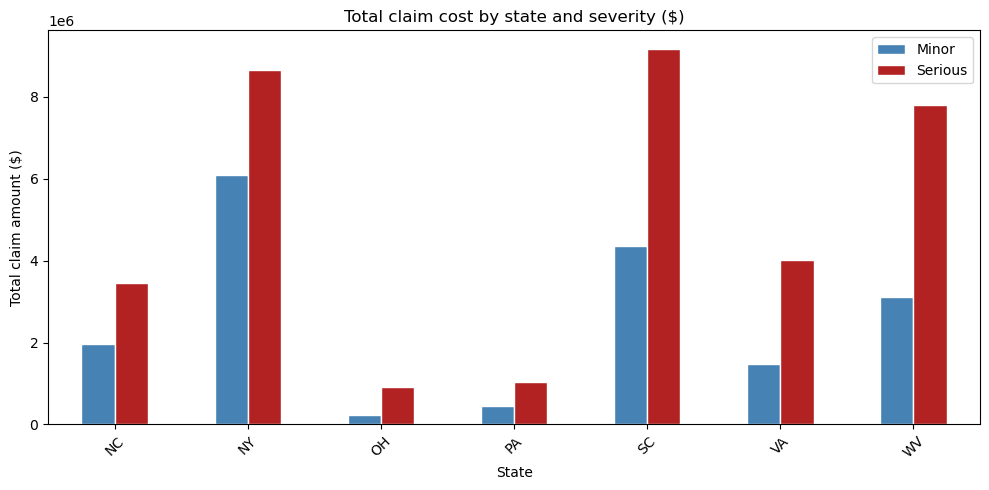

In [8]:
# Grouped bar chart - claim cost by state and severity 
regional_severity.plot(
    kind='bar',
    figsize=(10, 5),
    color=['steelblue', 'firebrick'],
    edgecolor='white')

plt.title('Total claim cost by state and severity ($)')
plt.xlabel('State')
plt.ylabel('Total claim amount ($)')
plt.xticks(rotation=45)
plt.legend(['Minor', 'Serious'])
plt.tight_layout()
plt.show()

Serious claims dominate total cost in every state. SC leads with 9.17M in serious claims followed by NY with 8.67M. 

Insurers operating in SC and NY should prioritize serious incident management and pricing review given their disproportionate claims cost. 

In [11]:
# Percentage of total claims for each collision type 
result = df['incident_type'].value_counts(normalize=True).round(3) *100
print(result)

incident_type
Multi-vehicle Collision     41.9
Single Vehicle Collision    40.3
Vehicle Theft                9.4
Parked Car                   8.4
Name: proportion, dtype: float64


In [13]:
# Police report gaps per collision types
collisions = df[df['incident_type'].isin(
    ['Multi-vehicle Collision', 'Single Vehicle Collision'])]

print(collisions['police_report_available'].value_counts())

police_report_available
Unknown    287
NO         271
YES        264
Name: count, dtype: int64


In [14]:
# Police report availability by collision type
police_by_type = collisions.groupby('incident_type')['police_report_available'].value_counts(
    normalize=True).round(3) * 100
                                    
print(police_by_type)

incident_type             police_report_available
Multi-vehicle Collision   Unknown                    36.0
                          NO                         33.2
                          YES                        30.8
Single Vehicle Collision  Unknown                    33.7
                          YES                        33.5
                          NO                         32.8
Name: proportion, dtype: float64


68% of collision claims have no confirmed police report, either unknown (35%) or explicitly absent (33%). This gap is consistent across both single and multi-vehicle collisions, suggesting a systemic documentation issue rather than fraud-specific behavior. Recommend mandatory police report submission for all collision claims above a defined threshold. 

In [16]:
# Single vehicle collision deep dive by age and region 
# Filtering single vehicle collisions 

svc = df[df['incident_type'] == 'Single Vehicle Collision'].copy()

# Bin age into groups 
svc['age_group'] = pd.cut(svc['age'],
    bins=[16, 25, 40, 65],
    labels=['Young (16-25)', 'Adult (26-40)', 'Middle Age (41-65)'])

print(svc['age_group'].value_counts())
print(f"\nTotal single vehicle collision claims: {len(svc)}")

age_group
Adult (26-40)         217
Middle Age (41-65)    171
Young (16-25)          15
Name: count, dtype: int64

Total single vehicle collision claims: 403


In [19]:
# Single vehicle collisions by region

regional_svc = svc.groupby('incident_state').agg(
    num_claims=('total_claim_amount', 'count'),
    avg_claim=('total_claim_amount', 'mean'),
    fraud_rate=('fraud_reported', lambda x: (x == 'Y').mean() * 100)
).round(1)

print(regional_svc.sort_values('fraud_rate', ascending=False))

                num_claims  avg_claim  fraud_rate
incident_state                                   
OH                       7    58917.1        57.1
NC                      43    63970.7        37.2
VA                      44    65504.8        31.8
SC                     105    65957.2        31.4
NY                     112    64478.8        27.7
PA                       9    58285.6        22.2
WV                      83    63306.5        20.5


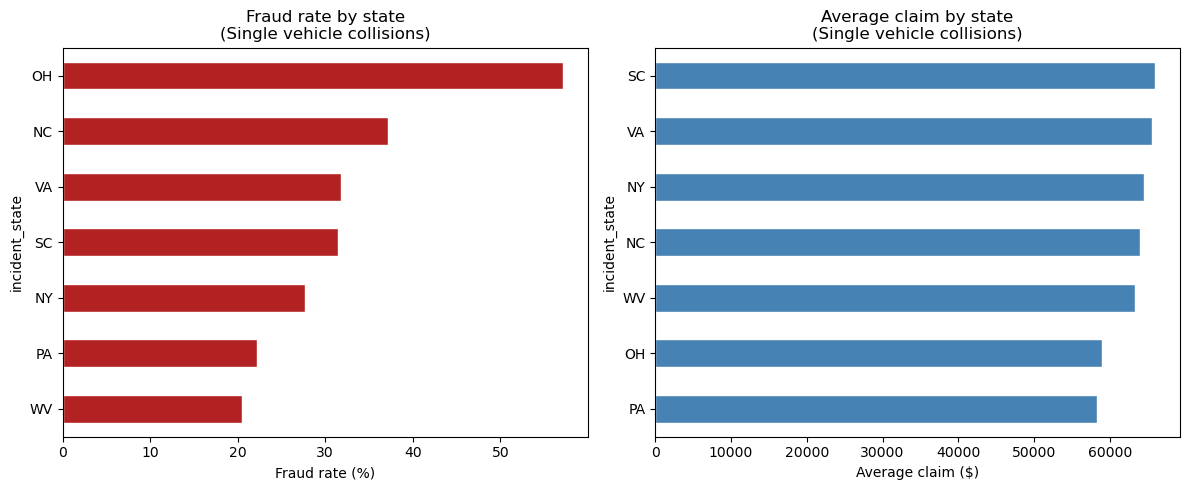

In [21]:
# Chart 1 - fraud rate by state
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
regional_svc['fraud_rate'].sort_values().plot(
    kind='barh', ax=ax1, color='firebrick', edgecolor='white')
ax1.set_title('Fraud rate by state\n(Single vehicle collisions)')
ax1.set_xlabel('Fraud rate (%)')

# Chart 2 - average claim by state
regional_svc['avg_claim'].sort_values().plot(
    kind='barh', ax=ax2, color='steelblue', edgecolor='white')
ax2.set_title('Average claim by state\n(Single vehicle collisions)')
ax2.set_xlabel('Average claim ($)')

plt.tight_layout()
plt.show()

Single vehicle collisions show significant fraud rate variation by state; SC (31.4%) and NC (37.2%) are highest priority. However, average claim amounts are consistent across all states (58K-65K), suggesting fraudulent claims are deliberately sized to appear legitimate. Recommend targeted investigation in SC and NC rather than amount-based flagging.

## Project 1 — Key Findings and Recommendations

### Finding 1: Fraud by incident type
Single vehicle collisions have the highest fraud rate at 29%, 
followed by multi-vehicle at 27.2%. Vehicle theft and parked 
car incidents are negligible fraud risks.

### Finding 2: Serious claims dominate cost
Serious claims (Major Damage + Total Loss) exceed minor claims 
in every state. SC leads at 9.17M in serious claims.

### Finding 3: Police report gap is systemic
68% of collision claims have no confirmed police report. This is 
consistent across both collision types, a systemic issue, not 
fraud-specific behavior.

### Finding 4: Single vehicle collisions — regional fraud hotspots
SC and NC show the highest fraud rates (31.4% and 37.2%) with 
large claim volumes. Average claim amounts are consistent across 
all states (58K-65K), suggesting fraud is size-neutral and 
deliberately designed to avoid detection.

### Overall Recommendation
Prioritize SC and NC for fraud investigation unit resources. 
Implement mandatory police report submission for all collision 
claims. Focus detection on claim patterns and frequency rather 
than claim amount thresholds.